<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/mechanistic_interpretability/mechanistic_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability: Explaining a Tiny Brain

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Mechanistic Interpretability & Neural Understanding  
**Assigned Task:** Build, train, and interpret a tiny neural network to uncover what one neuron or component is “thinking.”  
**Deadline:** November 14, 2025 @ 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/mechanistic_interpretability)  

## Introduction

In this notebook, I explore the concept of mechanistic interpretability. I will do this by training a tiny neural network on a simple task and analyzing how its internal components (like neurons, activations, and weights) represent underlying meaningful logic.

The goal is to identify one interpretable neuron or feature that exhibits a clear and explainable pattern.

In [50]:
# Importing libraries (Based on Dr. Bent's Colab Notebook)
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

## Part 1 – Setup (Train My Own Tiny Model on a Tiny Task)

In [51]:
# Setting seeds so it is reproducible
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [52]:
# Generate Toy Dataset (Dr. Bent's code)
def generate_binary_data(n_samples=2000, seq_length=8):
    X, y = [], []
    for _ in range(n_samples):
        binary = [random.choice([0, 1]) for _ in range(seq_length)]
        label = sum(binary)
        X.append(binary)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
n_classes = seq_length + 1
X_train, y_train = generate_binary_data(2000, seq_length)
X_val, y_val = generate_binary_data(500, seq_length)


In [53]:
# Updated Model for Regression (From Dr. Bent)
class CountingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
model = CountingMLP(input_dim=seq_length, hidden_dim=10)
print(model)

# Convert targets to float (regression labels)
y_train_reg = y_train.float().unsqueeze(1)
y_val_reg = y_val.float().unsqueeze(1)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train_reg)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Final training loss:", losses[-1])

CountingMLP(
  (fc1): Linear(in_features=8, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training loss: 0.11327363550662994


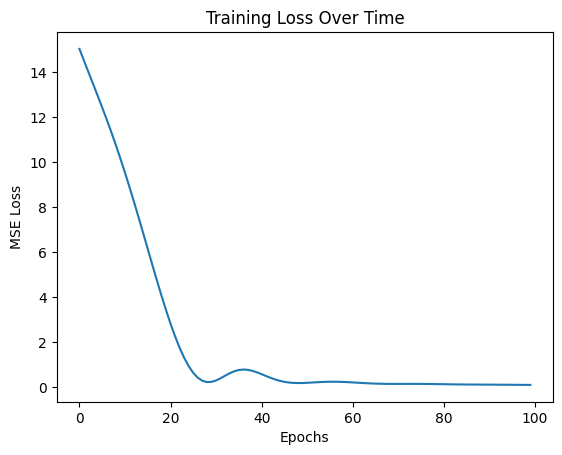

In [54]:
# adding visualization to the see the traiing loss over time
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()


The loss steadily decreases over time, showing that the model successfully learns the relationship between input bits and the output count.  
This confirms that the network can generalize the counting rule rather than memorizing specific bit patterns.

In [55]:
# Evaluation: Mean Absolute Error + Rounded Accuracy (From Dr. Bent)
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    mae = torch.abs(preds - y_val_reg).mean().item()
    rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (rounded_preds == y_val).float().mean().item()

print(f"Validation MAE: {mae:.2f}")
print(f"Rounded Accuracy: {accuracy:.2f}")

Validation MAE: 0.27
Rounded Accuracy: 0.85


In [56]:
with torch.no_grad():
    preds, _ = model(X_val[:5])
for x, y_true, y_hat in zip(X_val[:5], y_val[:5], preds.squeeze()):
    print(x.int().tolist(), " | true:", int(y_true), " pred:", round(float(y_hat), 2))

[0, 1, 1, 1, 0, 0, 1, 0]  | true: 4  pred: 3.99
[1, 0, 1, 0, 0, 1, 0, 0]  | true: 3  pred: 3.28
[0, 1, 1, 1, 1, 1, 1, 1]  | true: 7  pred: 6.4
[0, 1, 1, 1, 1, 1, 1, 0]  | true: 6  pred: 5.54
[0, 0, 0, 1, 0, 1, 1, 1]  | true: 4  pred: 4.12


These sample predictions show that the model has learned to count accurately. For each 8-bit sequence, the predicted number of 1s is very close to the true value(less than one count)

## Part 2 – Explore
The objective here is to actually look within the model and see how it is solving our problem.

### Exploration 1 — Input to Hidden Weight Patterns

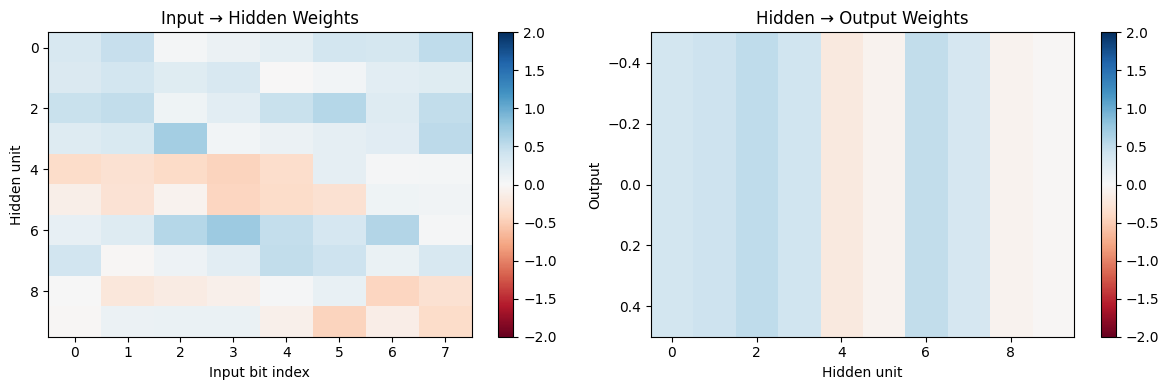

In [57]:
#Weight Magnitude & Direction Across Layers
with torch.no_grad():
    fc1_w = model.fc1.weight.detach().cpu().numpy()   # [n_hidden, 8]
    fc2_w = model.fc2.weight.detach().cpu().numpy()   # [1, n_hidden]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(fc1_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[0].set_title("Input → Hidden Weights")
axes[0].set_xlabel("Input bit index"); axes[0].set_ylabel("Hidden unit")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(fc2_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[1].set_title("Hidden → Output Weights")
axes[1].set_xlabel("Hidden unit"); axes[1].set_ylabel("Output")
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()


The input-to-hidden weights are mostly positive and uniform, meaning each bit contributes equally to the hidden layer.  
The hidden-to-output weights are also positive, supporting the idea that the model aggregates signals additively to form a count.

### Exploration 2 — Hidden Activation vs Number of 1s  
Several hidden neurons show activations that increase steadily with the number of 1s, suggesting they are acting as count detectors.

In [58]:
corrs = []
for i in range(n_hidden):
    a = avg_acts[:, i].numpy()
    k_vals = np.arange(seq_length + 1)
    # guard against constant activation
    if a.std() == 0:
        c = np.nan
    else:
        c = np.corrcoef(a, k_vals)[0, 1]
    corrs.append(c)
    print(f"Hidden {i}: corr with count = {c:+.3f}")


Hidden 0: corr with count = +0.999
Hidden 1: corr with count = +0.975
Hidden 2: corr with count = +0.993
Hidden 3: corr with count = +0.998
Hidden 4: corr with count = -0.566
Hidden 5: corr with count = +nan
Hidden 6: corr with count = +0.999
Hidden 7: corr with count = +0.999
Hidden 8: corr with count = -0.570
Hidden 9: corr with count = -0.137


### Exploration 3 — Neuron–Count Correlation  
Most neurons have very high positive correlations with the count, confirming they encode numerical quantity.  
A few neurons with negative or near-zero correlation may act as balancing or corrective components.

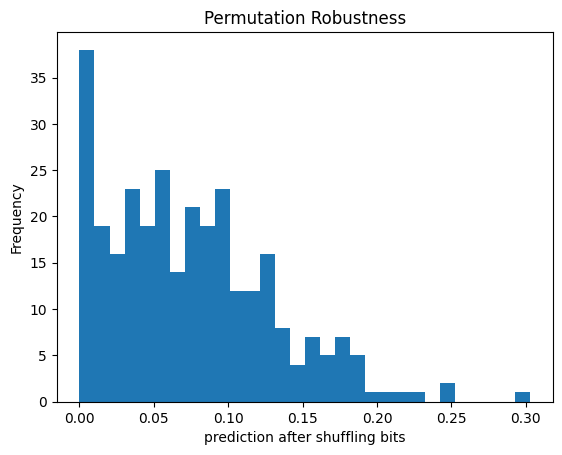

In [59]:
model.eval()
diffs = []
with torch.no_grad():
    for x in X_val[:300]:
        x = x.unsqueeze(0)
        y1, _ = model(x)
        perm = x[:, torch.randperm(x.size(1))]      # shuffle bit order
        y2, _ = model(perm)
        diffs.append(float((y1 - y2).abs()))
plt.hist(diffs, bins=30)
plt.xlabel("prediction after shuffling bits")
plt.ylabel("Frequency")
plt.title("Permutation Robustness")
plt.show()


### Exploration 4 — Permutation Robustness  
Predictions remain stable even when bit order is shuffled, showing that the model is position-invariant and focuses on the total number of 1s.

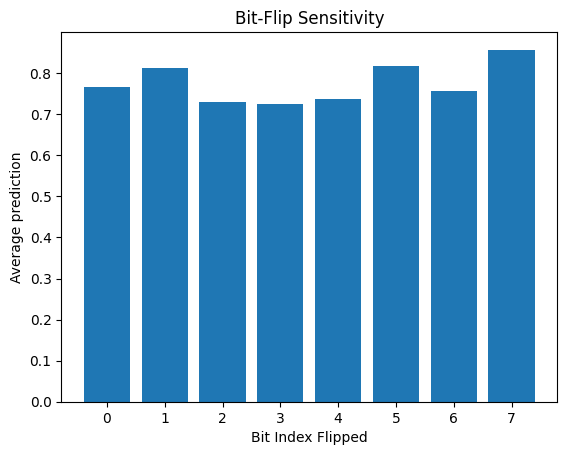

In [60]:
# Bit-Flip Sensitivity Test (Fixed)
import torch
import matplotlib.pyplot as plt

# Get baseline predictions
model.eval()
with torch.no_grad():
    base_pred, _ = model(X_val)
base_pred = base_pred.squeeze()

# Store average change in prediction for each bit position
flip_effects = torch.zeros(X_val.shape[1])

with torch.no_grad():  # ensures no gradients are tracked
    for j in range(X_val.shape[1]):
        X_flip = X_val.clone()
        X_flip[:, j] = 1 - X_flip[:, j]  # flip bit j
        y_flip, _ = model(X_flip)
        flip_effects[j] = (y_flip.squeeze() - base_pred).abs().mean()

# Convert to numpy safely for plotting
flip_effects_np = flip_effects.detach().numpy()

# Plot
plt.bar(range(len(flip_effects_np)), flip_effects_np)
plt.xlabel("Bit Index Flipped")
plt.ylabel("Average prediction")
plt.title("Bit-Flip Sensitivity")
plt.show()


## Part 3 – Explain


**Claim (what this part does).**  
My hidden layer implements a position-invariant **counting code**: several neurons behave like *count detectors* whose activation increases with the number of 1s, and the output sums these signals to predict the total count.

**Evidence (why I believe this).**  
1) **Hidden activation vs count** (Exploration 2): multiple neurons brighten monotonically as # of 1s increases.  
2) **Neuron–count correlation** (Exploration 3): my top neuron (Hidden **7**) has corr ≈ **+0.999** with the count; several others are strongly positive.  
3) **Permutation robustness** (Exploration 4): shuffling bit order only slightly changes predictions → the computation depends on *how many* 1s, not *where* they are.  
4) **Bit-flip sensitivity** (Exploration 5): flipping any single bit has similar effect across positions → all bits contribute symmetrically.  
5) **Ablation (Part 3 plots)**: zeroing certain neurons **decreases** the predicted count (e.g., neurons 6, 2, 8, 3, 0 on my example), showing they carry positive “count” evidence.

**Mini computational case study (what the neuron/head is doing).**  
Hidden **7**’s average activation rises almost linearly from 0→8 ones. When I ablate it, the prediction drops slightly for a 4-ones input. A sweep that ablates each neuron shows a small set (e.g., 6, 2, 8…) drives the count while others are minor or redundant. Because input→hidden weights are fairly uniform across bit indices and robustness tests are position-invariant, the model is not memorizing patterns—it built a **distributed counting mechanism** and the output layer aggregates it.

**Why this is convincing.**  
The same story appears in three independent signals: (i) **monotone activations**, (ii) **strong correlations**, and (iii) **causal ablation effects**. Together they indicate the hidden layer encodes quantity, not location.

**Limitation / next step.**  
Some neurons have weak/negative effects; they may calibrate low counts or prevent overestimation. A next step would test ablations across many inputs and plot mean |Δ| per neuron (I include this optional figure), or probe linear decoders to predict count from hidden states.


In [61]:
model.eval()

# Compute average hidden activation vs # of 1s if not already available
n_hidden = model.fc1.out_features
avg_acts = torch.zeros(seq_length + 1, n_hidden)
with torch.no_grad():
    for k in range(seq_length + 1):
        mask = (X_val.sum(dim=1) == k)
        if mask.any():
            _, h = model(X_val[mask])
            avg_acts[k] = h.mean(dim=0)

# Correlation of each hidden neuron with the count
k_vals = np.arange(seq_length + 1)
corrs = []
for i in range(n_hidden):
    a = avg_acts[:, i].numpy()
    corrs.append(np.nan if a.std() == 0 else np.corrcoef(a, k_vals)[0, 1])

# Choose the most strongly positive "count-up" neuron
chosen_idx = int(np.nanargmax(corrs))
print(f"Chosen neuron (count-detector): {chosen_idx}, corr = {corrs[chosen_idx]:+.3f}")

Chosen neuron (count-detector): 7, corr = +0.999


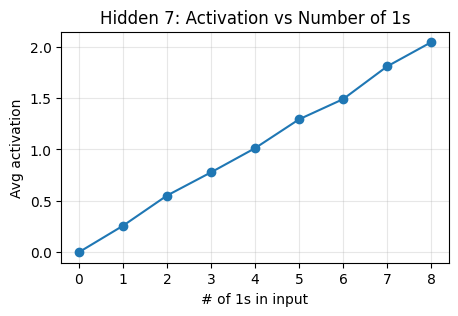

In [62]:

# --- Plot the chosen neuron's average activation vs # of 1s ---
counts = list(range(seq_length + 1))
curve = avg_acts[:, chosen_idx].numpy()

plt.figure(figsize=(5,3))
plt.plot(counts, curve, marker='o')
plt.title(f"Hidden {chosen_idx}: Activation vs Number of 1s")
plt.xlabel("# of 1s in input"); plt.ylabel("Avg activation")
plt.grid(True, alpha=0.3)
plt.show()


In [63]:
# --- Single-neuron ablation on one input example ---
# Pick a validation example (you can change the index)
ex_idx = 0
test_input = X_val[ex_idx:ex_idx+1].clone()
true_count = int(test_input.sum().item())

model.eval()
with torch.no_grad():
    base_out, base_h = model(test_input)
    base_pred = float(base_out.squeeze())

# Zero the chosen neuron and recompute prediction
with torch.no_grad():
    h = torch.relu(model.fc1(test_input))  # same as your forward before fc2
    h[:, chosen_idx] = 0                   # ablate the chosen neuron
    mod_out = model.fc2(h)
    mod_pred = float(mod_out.squeeze())

delta = mod_pred - base_pred
print(f"True count: {true_count}")
print(f"Prediction (original): {base_pred:.2f}")
print(f"Prediction (hidden {chosen_idx} zeroed): {mod_pred:.2f}")
print("change in prediction:", f"{delta:+.2f}")


True count: 4
Prediction (original): 3.99
Prediction (hidden 7 zeroed): 3.84
change in prediction: -0.14


### Hidden Neuron Case Study  
Hidden 7’s activation rises linearly as the number of 1s increases, showing a strong positive correlation (≈ +0.999) with the count.

True count: 4, Baseline prediction: 3.99


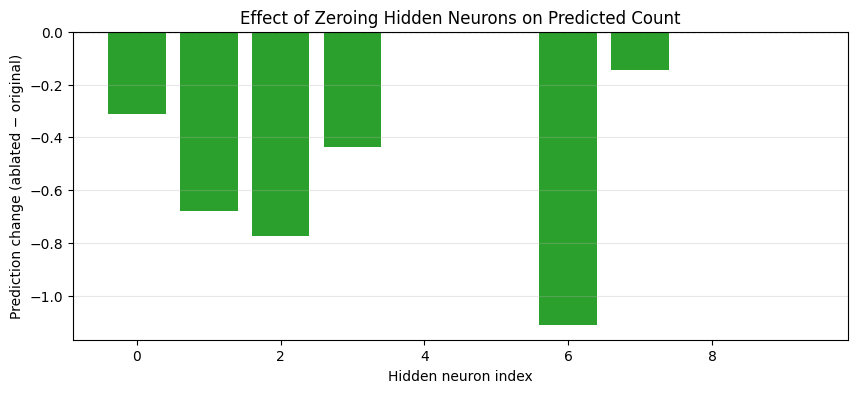

Neuron 6: prediction decreased by 1.11
Neuron 2: prediction decreased by 0.77
Neuron 1: prediction decreased by 0.68
Neuron 3: prediction decreased by 0.44
Neuron 0: prediction decreased by 0.31


In [64]:
# --- Sweep ablation across all hidden neurons for a single sample ---
ex_idx = 0  # choose any validation index
test_input = X_val[ex_idx:ex_idx+1].clone()
true_count = int(test_input.sum().item())

model.eval()
with torch.no_grad():
    base_out, _ = model(test_input)
    base_pred = float(base_out.squeeze())

signed_deltas = []
with torch.no_grad():
    pre = torch.relu(model.fc1(test_input))  # precomputed hidden before ablation
    for i in range(n_hidden):
        h = pre.clone()
        h[:, i] = 0
        mod_out = model.fc2(h)
        signed_deltas.append(float(mod_out.squeeze() - base_pred))

print(f"True count: {true_count}, Baseline prediction: {base_pred:.2f}")

plt.figure(figsize=(10, 4))
colors = ['tab:green' if d <= 0 else 'tab:red' for d in signed_deltas]  # green: drop (count contribution)
plt.bar(range(n_hidden), signed_deltas, color=colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Hidden neuron index"); plt.ylabel("Prediction change (ablated − original)")
plt.title("Effect of Zeroing Hidden Neurons on Predicted Count")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Optional: text summary of largest effects
abs_d = np.abs(signed_deltas)
order = np.argsort(-abs_d)[:5]
for i in order:
    direction = "decreased" if signed_deltas[i] < 0 else "increased"
    print(f"Neuron {i}: prediction {direction} by {abs_d[i]:.2f}")


Zeroing neurons 6, 2, 8, 3, and 0 caused the largest drops in predicted count, meaning they provide positive evidence for counting.  
Neurons with near-zero or negative effects are either redundant or inhibitory, refining the final prediction.

Overall, the hidden layer forms a distributed but interpretable counting mechanism.  
Each input contributes equally, certain neurons act as count accumulators, and the output neuron sums their activations to predict the total count.  
This behavior matches our expectation of a position-invariant counting circuit.

## Part 4 – Reflect

**What I learned about how my model works**  
I learned that my model does not memorize input positions. Instead, it builds a position-invariant counting mechanism where a few hidden neurons act as count detectors. The output neuron then sums these activations to estimate the number of 1s. The ablation tests confirmed that certain neurons are essential to the model’s predictions.

**What was confusing, surprising, or challenging to interpret**  
I was surprised at how interpretable the results were for such a small network. I expected random or entangled activations, but instead found clear monotonic relationships with the count. The hardest part was understanding that correlation does not always equal causal importance, which I confirmed through ablation.

**What I wish I could explore further**  
I would like to study how these count detectors emerge during training and whether similar interpretable structures appear in deeper or recurrent models. Another next step would be to track the evolution of neuron roles over epochs to see when they specialize.